# Analyse RFM, Dataset : "Online Retail"
### Segmentation client, loi de Pareto & restitution direction générale

**Structure du notebook :**
1. Chargement & Nettoyage des données
2. Construction du modèle RFM (Récence, Fréquence, Montant)
3. Segmentation client (règles métier + K-Means)
4. Analyse de Pareto (80/20)
5. Visualisations pour la direction générale
6. Synthèse exécutive 

> Source du dataset : [UCI Machine Learning Repository - Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)


In [3]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 1. Chargement & Nettoyage des données

**Question métier :** Nos données reflètent-elles des transactions réelles, ou contiennent-elles du bruit
(annulations, clients anonymes, valeurs aberrantes) qui fausserait le calcul du chiffre d'affaires ?


In [4]:
# Chargement 
import os

donnees = pd.read_excel("D:\\emman\\Desktop\\data\\onelineretail_analysis\\data\\processed\\Online Retail.xlsx")
donnees.head()
donnees.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
# Diagnostic de la qualité des données 
n_total = len(donnees)
n_na_customer = donnees['CustomerID'].isna().sum()
n_cancel = donnees['InvoiceNo'].astype(str).str.startswith('C').sum()
n_neg_qty = (donnees['Quantity'] <= 0).sum()
n_neg_price = (donnees['UnitPrice'] <= 0).sum()

diagnostic = pd.DataFrame({
    "Problème": ["Total lignes", "CustomerID manquant", "Annulations (InvoiceNo commence par C)",
                 "Quantité <= 0", "Prix unitaire <= 0"],
    "Nombre de lignes": [n_total, n_na_customer, n_cancel, n_neg_qty, n_neg_price],
    "% du total": [100, round(n_na_customer/n_total*100,1), round(n_cancel/n_total*100,1),
                   round(n_neg_qty/n_total*100,1), round(n_neg_price/n_total*100,1)]
})
diagnostic


,Problème,Nombre de lignes,% du total
0,Total lignes,541909,100.0
1,CustomerID manquant,135080,24.9
2,Annulations (InvoiceNo commence par C),9288,1.7
3,Quantité <= 0,10624,2.0
4,Prix unitaire <= 0,2517,0.5


In [6]:
# Nettoyage
donnees_nettoyees = donnees.copy()
donnees_nettoyees = donnees_nettoyees.dropna(subset=['CustomerID'])
donnees_nettoyees = donnees_nettoyees[~donnees_nettoyees['InvoiceNo'].astype(str).str.startswith('C')]
donnees_nettoyees = donnees_nettoyees[(donnees_nettoyees['Quantity'] > 0) & (donnees_nettoyees['UnitPrice'] > 0)]

donnees_nettoyees['InvoiceDate'] = pd.to_datetime(donnees_nettoyees['InvoiceDate'])
donnees_nettoyees['TotalPrice'] = donnees_nettoyees['Quantity'] * donnees_nettoyees['UnitPrice']
donnees_nettoyees['CustomerID'] = donnees_nettoyees['CustomerID'].astype(int)

print(f"Dimensions après nettoyage : {donnees_nettoyees.shape[0]} lignes ({donnees_nettoyees.shape[0]/n_total*100:.1f}% du volume initial)")
donnees_nettoyees.head()


Dimensions après nettoyage : 397884 lignes (73.4% du volume initial)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Seuil haut (IQR) : 42.48 € | Lignes au-dessus du seuil : 31241 (7.85%)


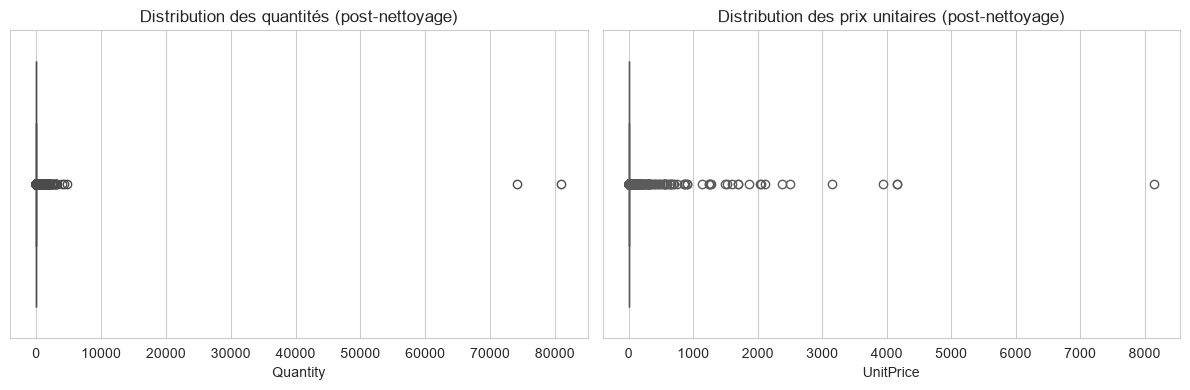

In [7]:
# Détection des valeurs aberrantes (méthode IQR) sur le montant de la ligne
Q1, Q3 = donnees_nettoyees['TotalPrice'].quantile([0.25, 0.75])
IQR = Q3 - Q1
seuil_haut = Q3 + 1.5 * IQR
n_outliers = (donnees_nettoyees['TotalPrice'] > seuil_haut).sum()
print(f"Seuil haut (IQR) : {seuil_haut:.2f} € | Lignes au-dessus du seuil : {n_outliers} ({n_outliers/len(donnees_nettoyees)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=donnees_nettoyees['Quantity'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution des quantités (post-nettoyage)')
sns.boxplot(x=donnees_nettoyees['UnitPrice'], ax=axes[1], color='#DD8452')
axes[1].set_title('Distribution des prix unitaires (post-nettoyage)')
plt.tight_layout()
plt.show()


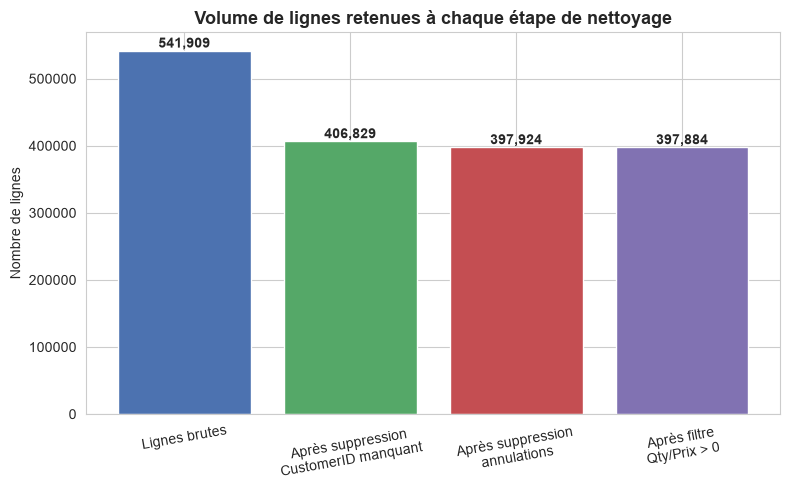

In [8]:
# Waterfall du nettoyage : combien de lignes retenues à chaque étape
steps = ['Lignes brutes', 'Après suppression\nCustomerID manquant', 'Après suppression\nannulations', 'Après filtre\nQty/Prix > 0']
step1 = n_total
step2 = donnees.dropna(subset=['CustomerID']).shape[0]
step3 = donnees.dropna(subset=['CustomerID'])[~donnees.dropna(subset=['CustomerID'])['InvoiceNo'].astype(str).str.startswith('C')].shape[0]
step4 = donnees_nettoyees.shape[0]
values = [step1, step2, step3, step4]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(steps, values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
ax.set_title("Volume de lignes retenues à chaque étape de nettoyage", fontsize=13, fontweight='bold')
ax.set_ylabel("Nombre de lignes")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


In [16]:
# Synthèse du Nettoyage 
from IPython.display import Markdown, display

pct_na = n_na_customer / n_total * 100
pct_cancel = n_cancel / n_total * 100
pct_final = donnees_nettoyees.shape[0] / n_total * 100

synthese_du_nettoyage = (
    f"Synthèse du nettoyage\n\n"
    f"> Sur **{n_total:,}** lignes brutes, **{pct_na:.1f} %** n'ont pas d'identifiant client "
    f"et **{pct_cancel:.1f} %** sont des annulations. Le dataset final exploitable représente "
    f"**{pct_final:.1f} %** du volume initial ({donnees_nettoyees.shape[0]:,} lignes), "
    f"garantissant une base fiable pour le calcul du chiffre d'affaires."
)
display(Markdown(synthese_du_nettoyage))


Synthèse du nettoyage

> Sur **541,909** lignes brutes, **24.9 %** n'ont pas d'identifiant client et **1.7 %** sont des annulations. Le dataset final exploitable représente **73.4 %** du volume initial (397,884 lignes), garantissant une base fiable pour le calcul du chiffre d'affaires.

## 2. Construction du modèle RFM

**Question métier :** Qui sont nos clients les plus précieux, et lesquels risquent de nous quitter ?

- **Récence (R)** : nombre de jours depuis le dernier achat
- **Fréquence (F)** : nombre de commandes distinctes
- **Montant (M)** : chiffre d'affaires total généré


In [17]:
# Date de référence = dernière date du dataset + 1 jour
snapshot_date = donnees_nettoyees['InvoiceDate'].max() + timedelta(days=1)
print(f"Date de référence (snapshot) : {snapshot_date.date()}")

rfm = donnees_nettoyees.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"Nombre de clients uniques : {rfm.shape[0]}")
rfm.describe().round(1)


Date de référence (snapshot) : 2011-12-10
Nombre de clients uniques : 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0,4338.0
mean,15300.4,92.5,4.3,2054.3
std,1721.8,100.0,7.7,8989.2
min,12346.0,1.0,1.0,3.8
25%,13813.2,18.0,1.0,307.4
50%,15299.5,51.0,2.0,674.5
75%,16778.8,142.0,5.0,1661.7
max,18287.0,374.0,209.0,280206.0


In [18]:
# Scoring RFM en quintiles (1 = faible, 5 = fort)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm['RFM_Segment_Code'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Segment_Code
0,12346,326,1,77183.60,1,1,5,7,115
1,12347,2,7,4310.00,5,5,5,15,555
2,12348,75,4,1797.24,2,4,4,10,244
3,12349,19,1,1757.55,4,1,4,9,414
4,12350,310,1,334.40,1,1,2,4,112


In [19]:
# Segmentation métier basée sur les scores R et F (approche standard RFM)
def assign_segment(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Clients fidèles'
    elif r >= 4 and f <= 2:
        return 'Nouveaux clients'
    elif r <= 2 and f >= 4:
        return 'À risque (At Risk)'
    elif r <= 2 and f <= 2:
        return 'Perdus (Hibernating)'
    else:
        return 'Clients réguliers'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
rfm['Segment'].value_counts()


Segment
Champions               1139
Perdus (Hibernating)    1065
Clients fidèles          821
Clients réguliers        719
Nouveaux clients         319
À risque (At Risk)       275
Name: count, dtype: int64

### Segmentation alternative non supervisée (K-Means)

Utile pour valider ou affiner la segmentation par règles métier.


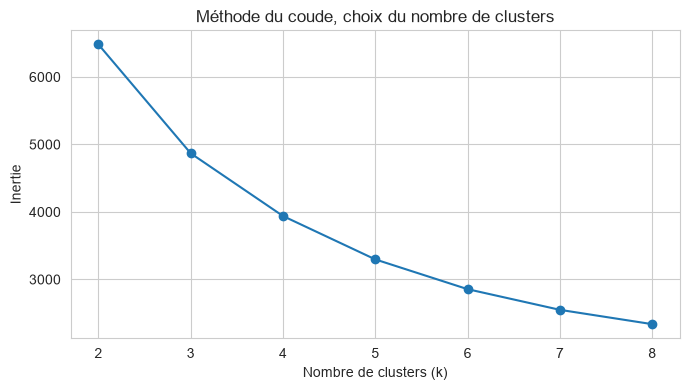

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardisation (log pour réduire l'asymétrie de Monetary/Frequency)
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log1p(x))
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Méthode du coude pour choisir k
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title("Méthode du coude, choix du nombre de clusters")
plt.tight_layout()
plt.show()


In [23]:
# Application K-Means avec le k retenu 
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)


,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,18.1,2.1,551.8
1,12.1,13.7,8074.3
2,71.1,4.1,1802.8
3,182.5,1.3,343.5


In [30]:
# Synthèse de la segmentation 
seg_stats = rfm.groupby('Segment').agg(
    Nb_Clients=('CustomerID', 'count'),
    CA=('Monetary', 'sum'),
    Monetary_moy=('Monetary', 'mean'),
    Recency_moy=('Recency', 'mean')
)
seg_stats['Pct_Clients'] = seg_stats['Nb_Clients'] / seg_stats['Nb_Clients'].sum() * 100
seg_stats['Pct_CA'] = seg_stats['CA'] / seg_stats['CA'].sum() * 100

champions_pct_clients = seg_stats.loc['Champions', 'Pct_Clients'] if 'Champions' in seg_stats.index else None
champions_pct_ca = seg_stats.loc['Champions', 'Pct_CA'] if 'Champions' in seg_stats.index else None
atrisk_present = 'À risque (At Risk)' in seg_stats.index
atrisk_monetary_moy = seg_stats.loc['À risque (At Risk)', 'Monetary_moy'] if atrisk_present else None
atrisk_recency_moy = seg_stats.loc['À risque (At Risk)', 'Recency_moy'] if atrisk_present else None

texte = "Synthèse de la segmentation\n\n> "
if champions_pct_clients is not None:
    texte += (f"Le segment **Champions** représente **{champions_pct_clients:.1f} %** des clients "
              f"mais **{champions_pct_ca:.1f} %** du chiffre d'affaires. ")
if atrisk_present:
    texte += (f"À l'inverse, le segment **À risque** conserve un montant moyen élevé "
              f"({atrisk_monetary_moy:,.0f}€) malgré une récence dégradée "
              f"({atrisk_recency_moy:.0f} jours en moyenne depuis le dernier achat) "
              f"cible prioritaire pour une action de rétention.")

display(Markdown(texte))
seg_stats.round(1)

Synthèse de la segmentation

> Le segment **Champions** représente **26.3 %** des clients mais **66.5 %** du chiffre d'affaires. À l'inverse, le segment **À risque** conserve un montant moyen élevé (1,575€) malgré une récence dégradée (137 jours en moyenne depuis le dernier achat) cible prioritaire pour une action de rétention.

,Nb_Clients,CA,Monetary_moy,Recency_moy,Pct_Clients,Pct_CA
Segment,,,,,,
Champions,1139,5927723.9,5204.3,13.3,26.3,66.5
Clients fidèles,821,1355744.7,1651.3,38.0,18.9,15.2
Clients réguliers,719,529127.2,735.9,110.4,16.6,5.9
Nouveaux clients,319,146166.6,458.2,18.5,7.4,1.6
Perdus (Hibernating),1065,519408.6,487.7,217.9,24.6,5.8
À risque (At Risk),275,433237.0,1575.4,137.1,6.3,4.9


## 3. Analyse de Pareto (règle des 80/20)

**Question métier :** Quels clients contribuent le plus à 80 % de notre chiffre d'affaires ?


In [31]:
# Tri des clients par CA décroissant + calcul du cumul
rfm_sorted = rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)
rfm_sorted['CumMonetary'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['CumPct'] = rfm_sorted['CumMonetary'] / rfm_sorted['Monetary'].sum() * 100
rfm_sorted['ClientRank_Pct'] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

# Clients qui, cumulés, représentent 80% du CA
clients_80pct = rfm_sorted[rfm_sorted['CumPct'] <= 80]
n_clients_80 = len(clients_80pct) + 1  # +1 pour inclure le client qui franchit le seuil
pct_clients_80 = n_clients_80 / len(rfm_sorted) * 100

print(f"{n_clients_80} clients sur {len(rfm_sorted)} ({pct_clients_80:.1f}% de la base) génèrent 80% du chiffre d'affaires.")


1133 clients sur 4338 (26.1% de la base) génèrent 80% du chiffre d'affaires.


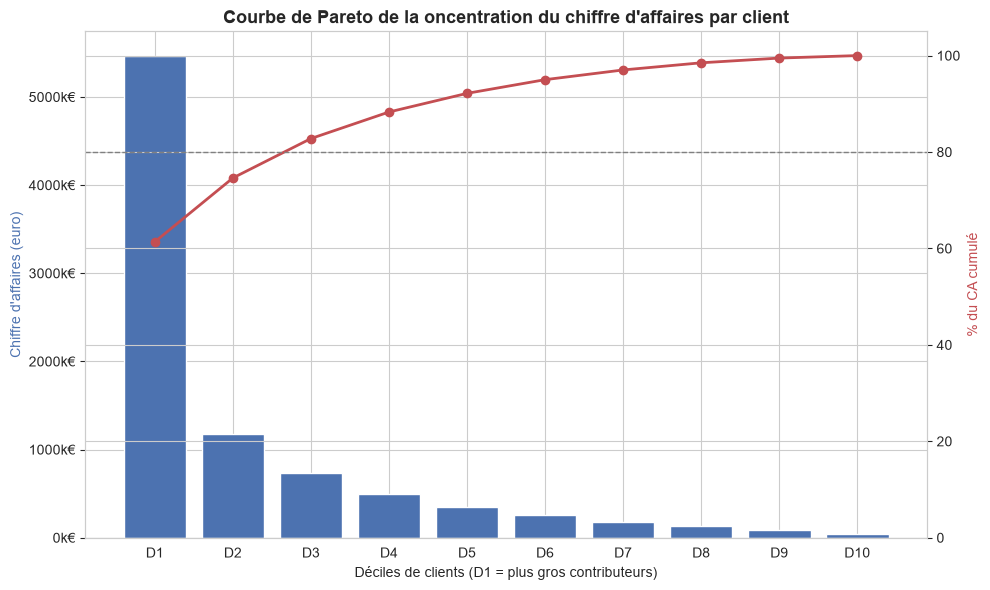

In [33]:
# Graphique de Pareto : barres (CA par décile de clients) + courbe cumulée
fig, ax1 = plt.subplots(figsize=(10, 6))

n_bins = 10
rfm_sorted['Decile'] = pd.qcut(rfm_sorted.index, n_bins, labels=[f'D{i+1}' for i in range(n_bins)])
decile_ca = rfm_sorted.groupby('Decile')['Monetary'].sum()

ax1.bar(decile_ca.index, decile_ca.values, color='#4C72B0', label='CA par décile de clients')
ax1.set_xlabel('Déciles de clients (D1 = plus gros contributeurs)')
ax1.set_ylabel('Chiffre d\'affaires (euro)', color='#4C72B0')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k€'))

ax2 = ax1.twinx()
cum_pct_by_decile = rfm_sorted.groupby('Decile')['Monetary'].sum().cumsum() / rfm_sorted['Monetary'].sum() * 100
ax2.plot(cum_pct_by_decile.index, cum_pct_by_decile.values, color='#C44E52', marker='o', linewidth=2, label='% CA cumulé')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('% du CA cumulé', color='#C44E52')
ax2.set_ylim(0, 105)

plt.title("Courbe de Pareto de la oncentration du chiffre d'affaires par client", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()



In [35]:
# Synthèse 
top_clients_ids = rfm_sorted.head(n_clients_80)['CustomerID']
top_clients_segments = rfm[rfm['CustomerID'].isin(top_clients_ids)]['Segment'].value_counts(normalize=True) * 100
segment_dominant = top_clients_segments.idxmax()
segment_dominant_pct = top_clients_segments.max()

texte = (
    f" Synthèse de la courbe de Pareto\n\n"
    f"> **{pct_clients_80:.1f} %** de nos clients (**{n_clients_80}** clients) génèrent **80 %** "
    f"de notre chiffre d'affaires. Parmi ces top clients, **{segment_dominant_pct:.0f} %** appartiennent "
    f"au segment **{segment_dominant}**, une perte de ce noyau aurait un impact disproportionné sur le CA."
)
display(Markdown(texte))


 Synthèse de la courbe de Pareto

> **26.1 %** de nos clients (**1133** clients) génèrent **80 %** de notre chiffre d'affaires. Parmi ces top clients, **65 %** appartiennent au segment **Champions**, une perte de ce noyau aurait un impact disproportionné sur le CA.

## 4. Visualisations pour la direction générale

Trois graphiques maximum, pensés pour une lecture rapide en comité de direction.


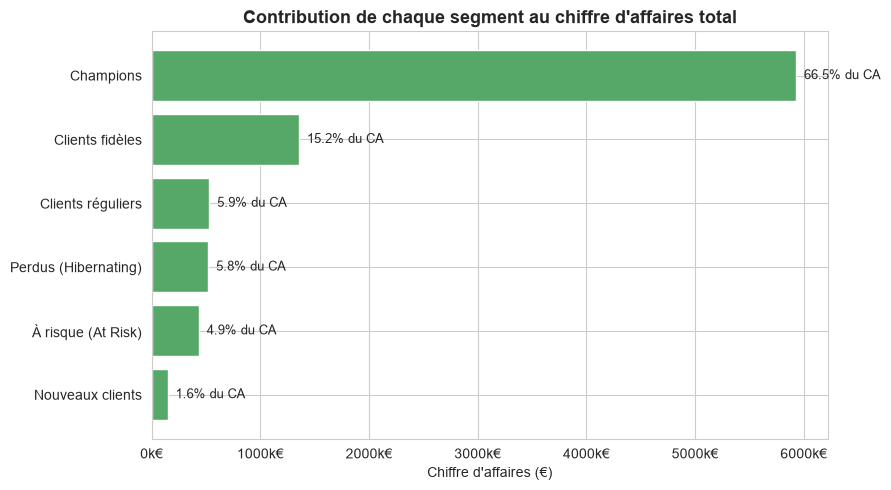

,Nb_Clients,CA_Total,Panier_Moyen,Pct_CA,Pct_Clients
Segment,,,,,
Nouveaux clients,319,146166.6,458.2,1.6,7.4
À risque (At Risk),275,433237.0,1575.4,4.9,6.3
Perdus (Hibernating),1065,519408.6,487.7,5.8,24.6
Clients réguliers,719,529127.2,735.9,5.9,16.6
Clients fidèles,821,1355744.7,1651.3,15.2,18.9
Champions,1139,5927723.9,5204.3,66.5,26.3


In [38]:
#  Poids de chaque segment dans le CA total 
segment_summary = rfm.groupby('Segment').agg(
    Nb_Clients=('CustomerID', 'count'),
    CA_Total=('Monetary', 'sum'),
    Panier_Moyen=('Monetary', 'mean')
).sort_values('CA_Total', ascending=True)

segment_summary['Pct_CA'] = segment_summary['CA_Total'] / segment_summary['CA_Total'].sum() * 100
segment_summary['Pct_Clients'] = segment_summary['Nb_Clients'] / segment_summary['Nb_Clients'].sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(segment_summary.index, segment_summary['CA_Total'], color='#55A868')
for bar, pct in zip(bars, segment_summary['Pct_CA']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'  {pct:.1f}% du CA',
            va='center', fontsize=9)
ax.set_xlabel("Chiffre d'affaires (€)")
ax.set_title("Contribution de chaque segment au chiffre d'affaires total", fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k€'))
plt.tight_layout()
plt.show()

segment_summary.round(1)


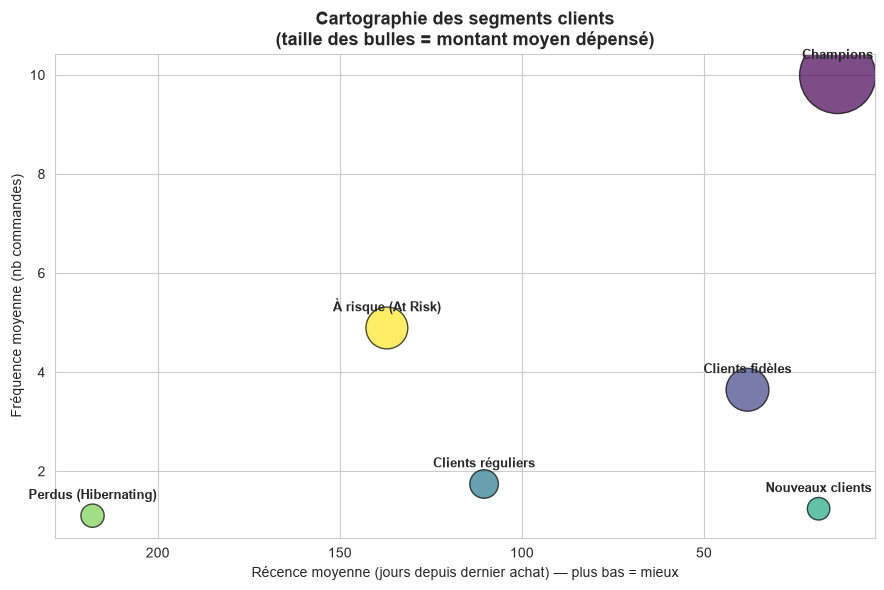

In [37]:
# Positionnement des segments : Récence x Fréquence, taille = Montant moyen
seg_position = rfm.groupby('Segment').agg(
    Recency_moy=('Recency', 'mean'),
    Frequency_moy=('Frequency', 'mean'),
    Monetary_moy=('Monetary', 'mean'),
    Nb_Clients=('CustomerID', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    seg_position['Recency_moy'], seg_position['Frequency_moy'],
    s=seg_position['Monetary_moy'] / seg_position['Monetary_moy'].max() * 3000,
    c=range(len(seg_position)), cmap='viridis', alpha=0.7, edgecolors='black'
)
for _, row in seg_position.iterrows():
    ax.annotate(row['Segment'], (row['Recency_moy'], row['Frequency_moy']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel("Récence moyenne (jours depuis dernier achat) — plus bas = mieux")
ax.set_ylabel("Fréquence moyenne (nb commandes)")
ax.set_title("Cartographie des segments clients\n(taille des bulles = montant moyen dépensé)", fontsize=13, fontweight='bold')
ax.invert_xaxis()  # récence faible (bon) à droite
plt.tight_layout()
plt.show()


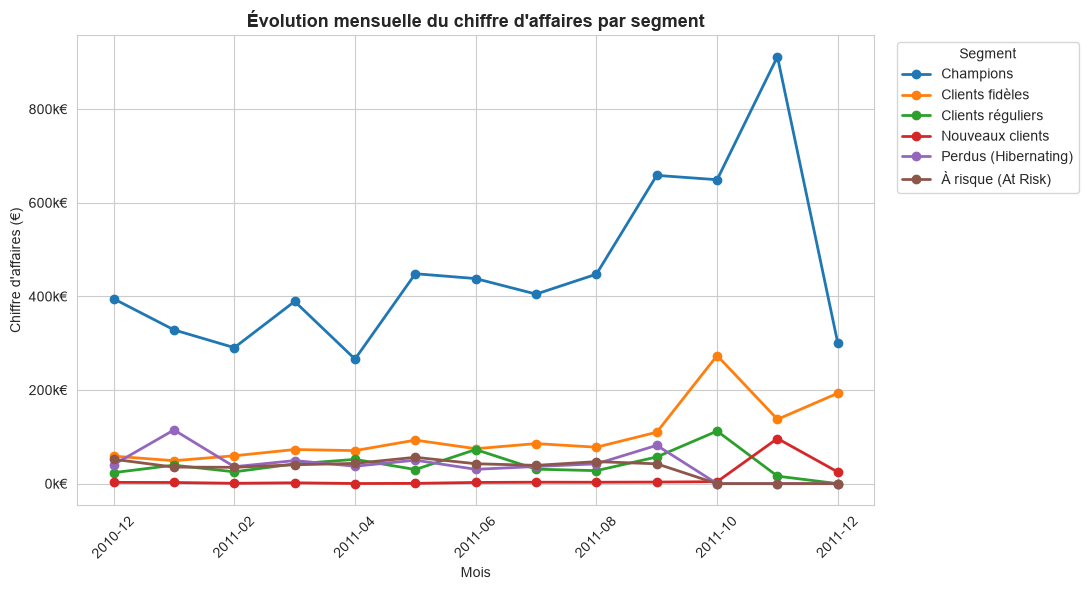

In [39]:
# Évolution mensuelle du CA par segment (détection de dégradation)
donnees_nettoyees = donnees_nettoyees.merge(rfm[['CustomerID', 'Segment']], on='CustomerID', how='left')
donnees_nettoyees['YearMonth'] = donnees_nettoyees['InvoiceDate'].dt.to_period('M').astype(str)

monthly_ca = donnees_nettoyees.groupby(['YearMonth', 'Segment'])['TotalPrice'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
monthly_ca.plot(ax=ax, marker='o', linewidth=2)
ax.set_title("Évolution mensuelle du chiffre d'affaires par segment", fontsize=13, fontweight='bold')
ax.set_ylabel("Chiffre d'affaires (€)")
ax.set_xlabel("Mois")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k€'))
plt.xticks(rotation=45)
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Synthèse exécutive 

Rassembler les indicateurs clés générés automatiquement à partir de l'analyse.


In [40]:
# Génération automatique des indicateurs clés pour la synthèse
top_segment = segment_summary['CA_Total'].idxmax()
top_segment_pct_ca = segment_summary.loc[top_segment, 'Pct_CA']
top_segment_pct_clients = segment_summary.loc[top_segment, 'Pct_Clients']

at_risk_present = 'À risque (At Risk)' in segment_summary.index
at_risk_ca = segment_summary.loc['À risque (At Risk)', 'CA_Total'] if at_risk_present else 0

print("="*70)
print("SYNTHÈSE EXÉCUTIVE — ANALYSE RFM ONLINE RETAIL")
print("="*70)
print(f"• Base client exploitable : {rfm.shape[0]} clients ({donnees_nettoyees.shape[0]} transactions valides)")
print(f"• Pareto : {pct_clients_80:.1f}% des clients ({n_clients_80}) génèrent 80% du CA")
print(f"• Segment le plus rentable : '{top_segment}' -> {top_segment_pct_ca:.1f}% du CA "
      f"pour seulement {top_segment_pct_clients:.1f}% des clients")
if at_risk_present:
    print(f"• Risque identifié : le segment 'À risque' représente encore {at_risk_ca:,.0f}€ de CA "
          f"historique à réactiver en priorité")
print("="*70)


SYNTHÈSE EXÉCUTIVE — ANALYSE RFM ONLINE RETAIL
• Base client exploitable : 4338 clients (397884 transactions valides)
• Pareto : 26.1% des clients (1133) génèrent 80% du CA
• Segment le plus rentable : 'Champions' -> 66.5% du CA pour seulement 26.3% des clients
• Risque identifié : le segment 'À risque' représente encore 433,237€ de CA historique à réactiver en priorité


---
### Recommandations types à intégrer dans la présentation

1. **Fidéliser en priorité** le segment Champions (programme VIP, accès anticipé aux nouveautés)
2. **Réactiver** le segment "À risque" via une campagne emailing ciblée avant qu'ils ne basculent en "Perdus"
3. **Convertir** les nouveaux clients en clients réguliers via un parcours d'onboarding (2ᵉ achat sous 30 jours)
4. **Suivre mensuellement** l'évolution du CA par segment comme KPI de santé du portefeuille client
